## 46-886

## Classification Trees with Cross-Validation

### Application: Loan Default
 

Amr Farahat

CMU / Tepper

2023-03-18

---

-  0 denotes good risk (i.e. accept and issue load).
-  1 denotes bad risk (i.e. decline)

## Setting up

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
conda update anaconda

Retrieving notices: ...working... done
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - anaconda


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    anaconda-client-1.11.2     |   py39hecd8cb5_0         142 KB
    boltons-23.0.0             |   py39hecd8cb5_0         423 KB
    conda-23.3.1               |   py39hecd8cb5_0         962 KB
    conda-repo-cli-1.0.41      |   py39hecd8cb5_0         123 KB
    jsonpatch-1.32             |     pyhd3eb1b0_0          15 KB
    jsonpointer-2.1            |     pyhd3eb1b0_0           9 KB
    libllvm14-14.0.6           |       h91fad77_2        24.1 MB
    requests-toolbelt-0.9.1    |     pyhd3eb1b0_0          42 KB
    ------------------------------------------------------------
                                           Total:        25.8 MB

The following NEW packages will be IN

In [48]:
conda install -c anaconda graphviz

Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_graphviz
from graphviz import Source

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [51]:
pd.options.display.max_columns = None

In [52]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

## Importing data

In [53]:
df = pd.read_csv("loans.csv")

In [54]:
df

,default,installment,log_income,fico_score,rev_balance,inquiries,records
0,0,829,4.93,737,28.85,0,0
1,0,228,4.81,707,33.62,0,0
2,0,367,4.51,682,3.51,1,0
3,0,162,4.93,712,33.67,1,0
4,0,103,4.91,667,4.74,0,0
...,...,...,...,...,...,...,...
9511,1,345,5.29,672,215.37,2,0
9512,1,258,4.84,722,0.18,5,0
9513,1,98,4.60,687,10.04,8,0
9514,1,352,4.70,692,0.00,5,0


## Train / Test split

In [55]:
y = df["default"]
X = df.drop("default", axis=1)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=886)

## Setting a classification threshold

In [57]:
mythreshold = 0.2

## Classification tree (max depth = 5; no CV)

In [58]:
treemod = DecisionTreeClassifier(max_depth=5, random_state=886)
treemod.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=886)

In [59]:
export_graphviz(
        treemod,
        out_file="loans_tree.dot",
        feature_names=X_train.columns,
        impurity=False,
        rounded=True,
        filled=True
    )

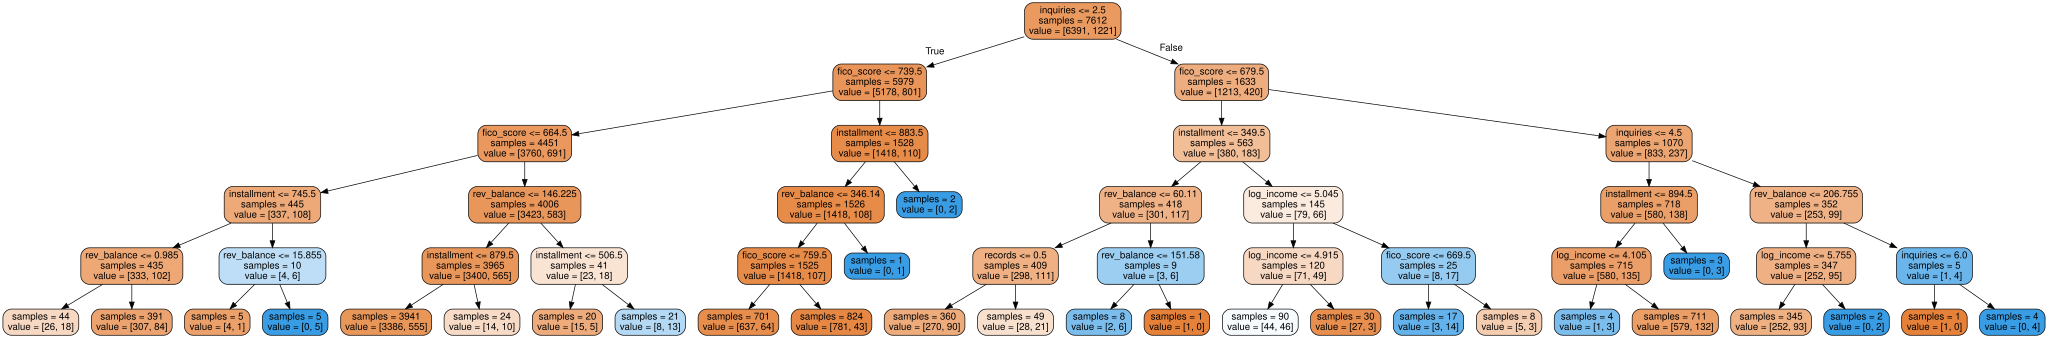

In [60]:
Source.from_file("loans_tree.dot")

Reference:
https://scikit-learn.org/stable/modules/tree.html#mathematical-formulation

In [61]:
treemod_pred_prob = treemod.predict_proba(X_test)

In [62]:
treemod_pred_prob

array([[0.8591728 , 0.1408272 ],
       [0.81434599, 0.18565401],
       [0.73043478, 0.26956522],
       ...,
       [0.8591728 , 0.1408272 ],
       [0.78516624, 0.21483376],
       [0.8591728 , 0.1408272 ]])

In [63]:
treemod_decisions = (treemod_pred_prob[:,1] >= mythreshold).astype(int)
treemod_decisions

array([0, 0, 1, ..., 0, 1, 0])

In [64]:
treemod_cm = confusion_matrix(y_test, treemod_decisions)
treemod_cm

array([[1346,  258],
       [ 193,  107]])

In [65]:
treemod_cm[1,0]

193

In [66]:
accuracy_score(y_test, treemod_decisions)

0.7631302521008403

In [67]:
sensitivity  = treemod_cm[1,1]/ (treemod_cm[1,1] + treemod_cm[1,0]) 
sensitivity

0.3566666666666667

In [68]:
specificity  = treemod_cm[0,0]/ (treemod_cm[0,0] + treemod_cm[0,1]) 
specificity

0.8391521197007481

In [69]:
fpr, tpr, thresholds = roc_curve(y_test, treemod_pred_prob[:,1])

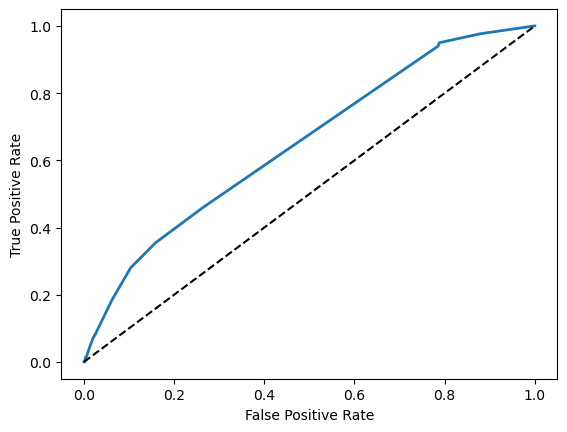

In [70]:
plot_roc_curve(fpr,tpr)
plt.show()

In [71]:
roc_auc_score(y_test, treemod_pred_prob[:,1])

0.6505746051537822

In [72]:
treemod_cm

array([[1346,  258],
       [ 193,  107]])

In [73]:
treemod_cm[0,0]

1346

In [74]:
treemod_cm[1,0]

193

In [75]:
sum(sum(treemod_cm))

1904

In [76]:
treemod_profit = (1000 * treemod_cm[0,0] - 4000 * treemod_cm[1,0] ) / sum(sum(treemod_cm))
treemod_profit

301.47058823529414

## Classification tree with CV

In [77]:
treemod.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 886,
 'splitter': 'best'}

In [78]:
param_grid = [
  {'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10]} 
]

In [79]:
cv_grid = GridSearchCV(treemod, param_grid, scoring="roc_auc")

In [80]:
cv_grid.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(max_depth=5, random_state=886),
             param_grid=[{'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10]}],
             scoring='roc_auc')

In [81]:
pd.DataFrame(cv_grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008581,0.002427,0.002740,0.000774,2,{'max_depth': 2},0.618559,0.600141,0.619156,0.610457,0.622154,0.614093,0.007981,5
1,0.005928,0.000582,0.001522,0.000168,3,{'max_depth': 3},0.628775,0.609206,0.622499,0.601373,0.623195,0.617009,0.010121,3
2,0.006368,0.000015,0.001293,0.000006,4,{'max_depth': 4},0.634419,0.612411,0.626324,0.600078,0.635352,0.621717,0.013589,1
3,0.007621,0.000036,0.001295,0.000011,5,{'max_depth': 5},0.615840,0.607721,0.629029,0.603565,0.635127,0.618257,0.012111,2
4,0.008907,0.000080,0.001313,0.000016,6,{'max_depth': 6},0.638590,0.607191,0.618256,0.582618,0.626113,0.614553,0.018969,4
5,0.010163,0.000044,0.001334,0.000019,7,{'max_depth': 7},0.617491,0.610745,0.612676,0.579934,0.617979,0.607765,0.014188,6
6,0.011380,0.000023,0.001336,0.000014,8,{'max_depth': 8},0.601440,0.620838,0.606237,0.550216,0.617695,0.599285,0.025551,7
7,0.012576,0.000033,0.001350,0.000014,9,{'max_depth': 9},0.591760,0.613559,0.577944,0.554282,0.614315,0.590372,0.022670,8
8,0.013758,0.000068,0.001346,0.000003,10,{'max_depth': 10},0.601174,0.606817,0.561236,0.553242,0.586062,0.581706,0.021250,9


## 6.3. Retraining and assessing the final model

In [82]:
treemod_final = DecisionTreeClassifier(max_depth=4, random_state=886)
treemod_final.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=886)

In [83]:
export_graphviz(
        treemod_final,
        out_file="loans_tree_final.dot",
        feature_names=X_train.columns,
        impurity=False,
        rounded=True,
        filled=True
    )

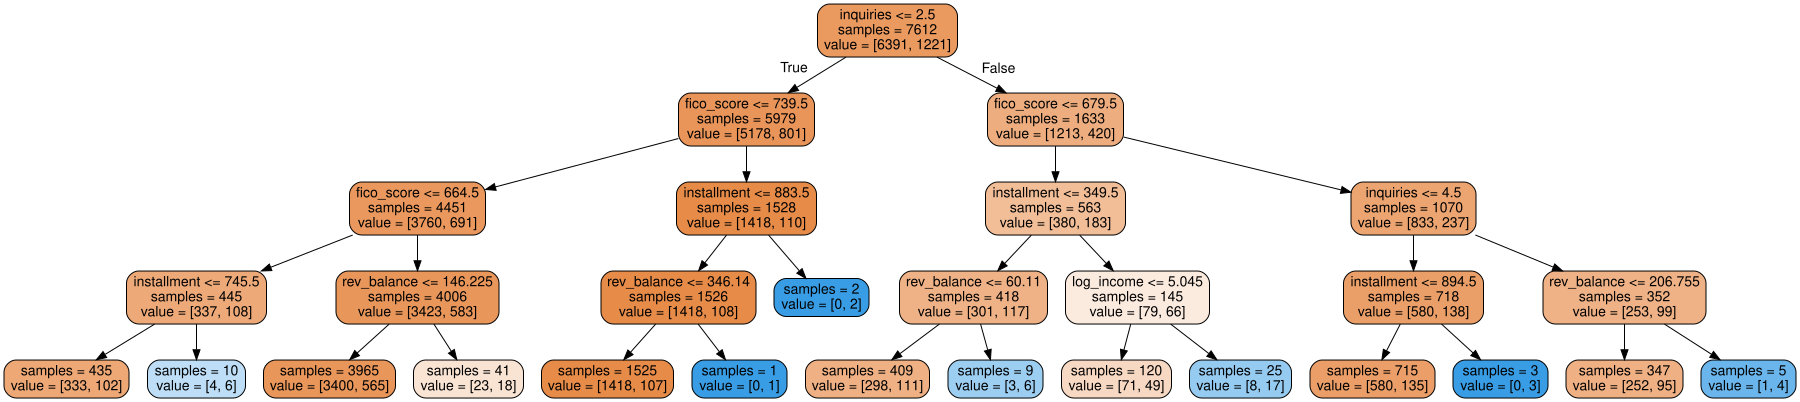

In [84]:
Source.from_file("loans_tree_final.dot")

Reference:
https://scikit-learn.org/stable/modules/tree.html#mathematical-formulation

In [85]:
treemod_final_pred_prob = treemod_final.predict_proba(X_test)

In [86]:
treemod_final_decisions = (treemod_final_pred_prob[:,1] >= mythreshold).astype(int)

In [87]:
treemod_final_cm = confusion_matrix(y_test, treemod_final_decisions)
treemod_final_cm

array([[1341,  263],
       [ 194,  106]])

In [88]:
accuracy_score(y_test, treemod_final_decisions)

0.7599789915966386

In [89]:
fpr, tpr, thresholds = roc_curve(y_test, treemod_final_pred_prob[:,1])

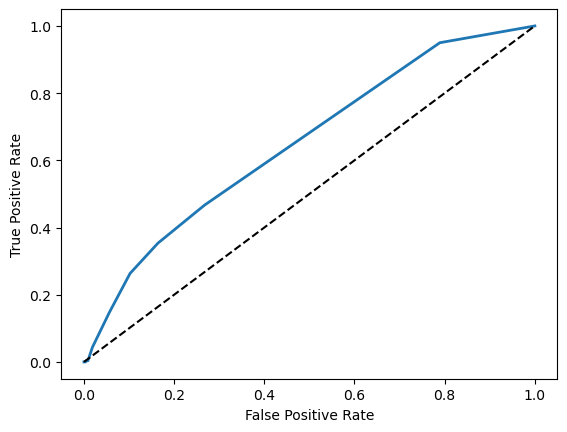

In [90]:
plot_roc_curve(fpr,tpr)
plt.show()

In [91]:
roc_auc_score(y_test, treemod_final_pred_prob[:,1])

0.649799459684123

In [92]:
treemod_final_profit = (1000 * treemod_final_cm[0,0] - 4000 * treemod_final_cm[1,0] ) / sum(sum(treemod_final_cm))
treemod_final_profit

296.7436974789916

### END